# Análisis de Estrategias de Fusión - HybridRank RAG

Este notebook analiza los resultados de la evaluación comparativa
de diferentes estrategias de fusión para el sistema HybridRank RAG.

**Prerequisito**: Ejecutar `experiments/evaluate_fusion_strategies.py` para generar los datos.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

RESULTS_DIR = Path('../experiments/results')
df = pd.read_csv(RESULTS_DIR / 'fusion_metrics.csv')

METRIC_COLS = ['recall', 'precision', 'f1', 'mrr', 'map', 'ndcg']
BASELINES = ['bm25_only', 'dense_only']
FUSION_STRATEGIES = [s for s in df['strategy'].unique() if s not in BASELINES and 'hybridrank' not in s]
HR_STRATEGIES = [s for s in df['strategy'].unique() if 'hybridrank' in s]

print(f'Total filas: {len(df)}')
print(f'Estrategias: {df["strategy"].nunique()} ({len(BASELINES)} baselines, {len(FUSION_STRATEGIES)} fusion, {len(HR_STRATEGIES)} hybridrank)')
print(f'Queries: {df["query_id"].nunique()}')
print(f'Valores de k: {sorted(df["top_k"].unique())}')
print(f'NaN totales: {df[METRIC_COLS].isnull().sum().sum()}')
df.head()

Total filas: 960
Estrategias: 16 (2 baselines, 9 fusion, 5 hybridrank)
Queries: 20
Valores de k: [5, 10, 20]
NaN totales: 0


,top_k,recall,precision,f1,mrr,map,ndcg,strategy,query_id,query_type,retriever_name
0,5,0.384615,1.0,0.555556,1.0,0.384615,1.000000,bm25_only,q1,referencia_exacta,bm25_only
1,10,0.769231,1.0,0.869565,1.0,0.769231,1.000000,bm25_only,q1,referencia_exacta,bm25_only
2,20,0.923077,0.6,0.727273,1.0,0.923077,0.950956,bm25_only,q1,referencia_exacta,bm25_only
3,5,0.666667,0.8,0.727273,1.0,0.536111,0.786014,bm25_only,q2,referencia_exacta,bm25_only
4,10,1.000000,0.6,0.750000,1.0,0.786111,0.900172,bm25_only,q2,referencia_exacta,bm25_only


## 1. Vista General: Tabla Agregada por Estrategia

In [9]:
# Resumen por estrategia (promedio sobre todas las queries y k_values)
summary = df.groupby('strategy')[METRIC_COLS].mean().round(4)
summary = summary.sort_values('ndcg', ascending=False)
summary.style.background_gradient(cmap='RdYlGn', axis=0)

,recall,precision,f1,mrr,map,ndcg
strategy,,,,,,
combsum_zscore,0.694900,0.620000,0.567700,0.941700,0.593600,0.838800
combsum_minmax,0.678700,0.608300,0.555900,0.950000,0.583900,0.830800
weighted_a0.5,0.678700,0.608300,0.555900,0.950000,0.583900,0.830800
weighted_a0.3,0.649000,0.595800,0.538500,0.916700,0.555100,0.804400
weighted_a0.7,0.676500,0.577500,0.539100,0.929800,0.560200,0.801100
hybridrank_a0.7_b0.3,0.668300,0.567500,0.532000,0.935000,0.548800,0.793700
combmnz_minmax,0.646800,0.554200,0.520000,0.950000,0.539000,0.778900
bm25_only,0.639500,0.559200,0.512900,0.929800,0.536200,0.778700
hybridrank_a0.5_b0.5,0.646300,0.540000,0.511600,0.950000,0.533500,0.768800


## 2. Baselines vs Estrategias de Fusion (k=10)

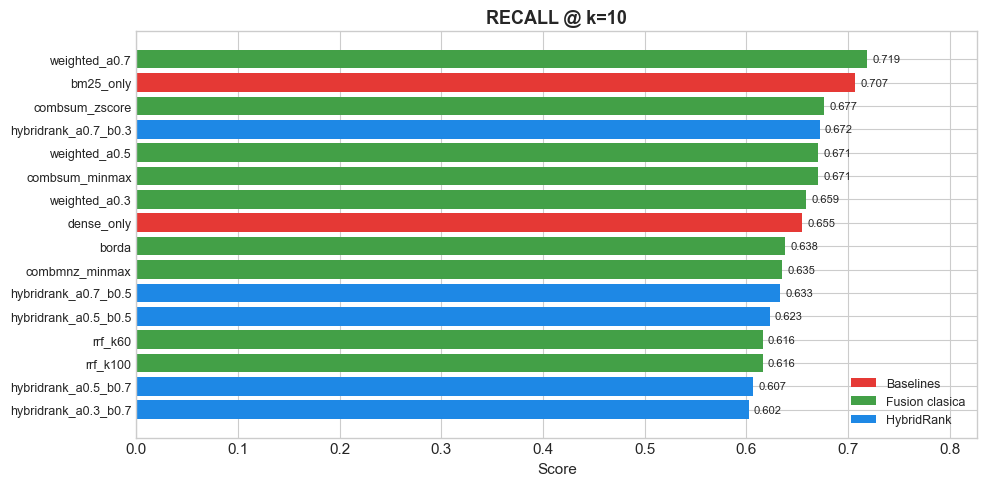

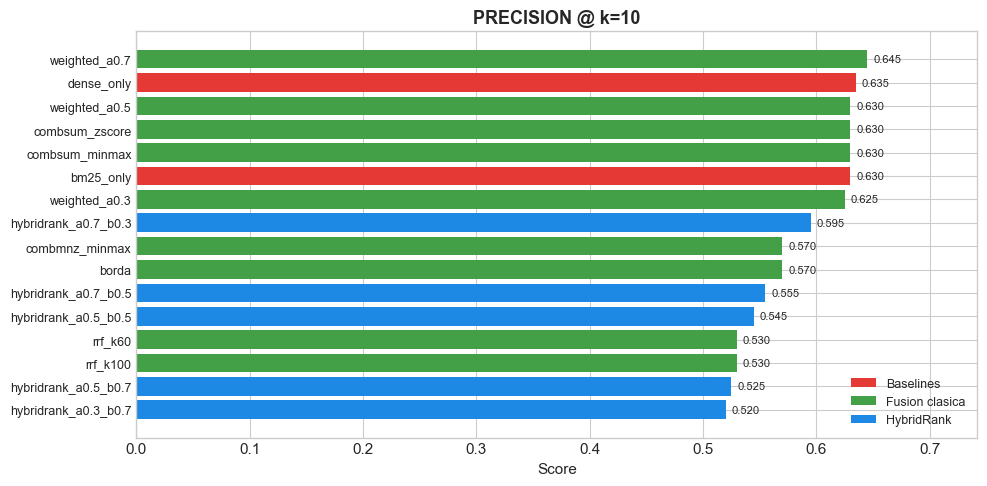

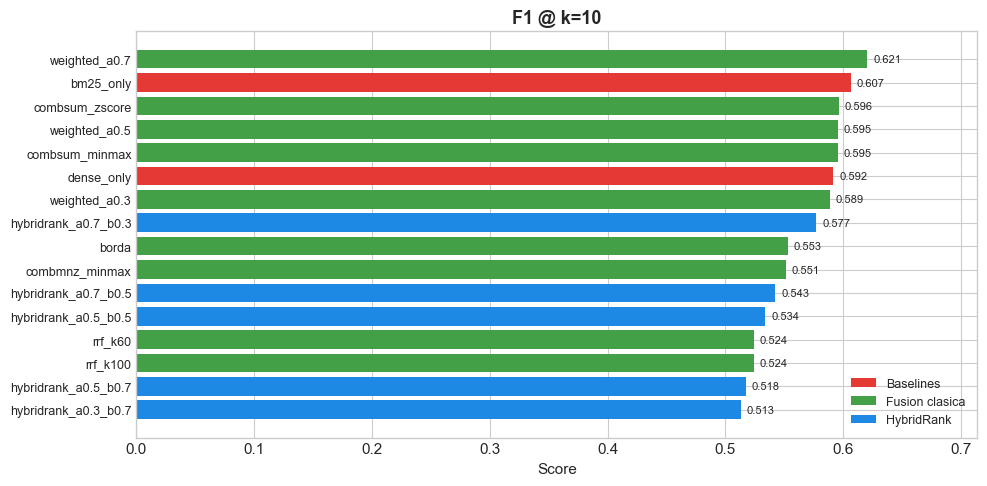

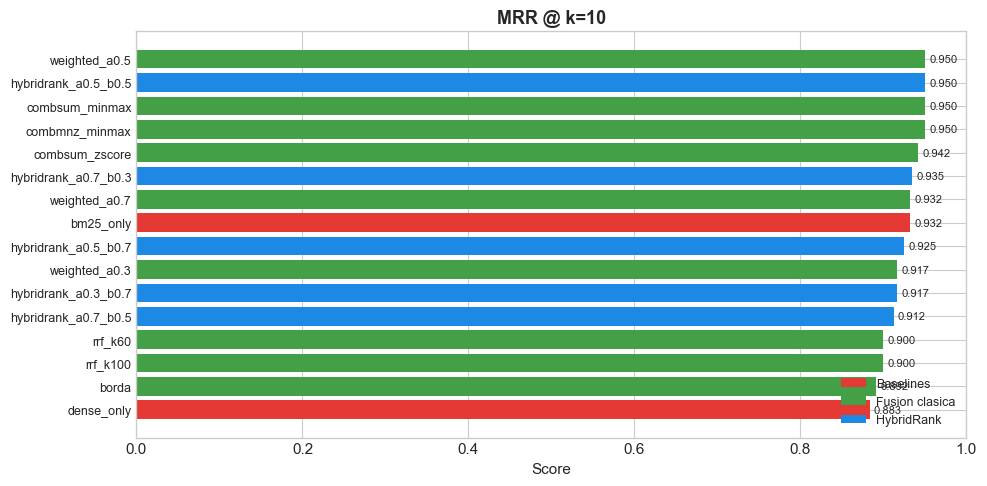

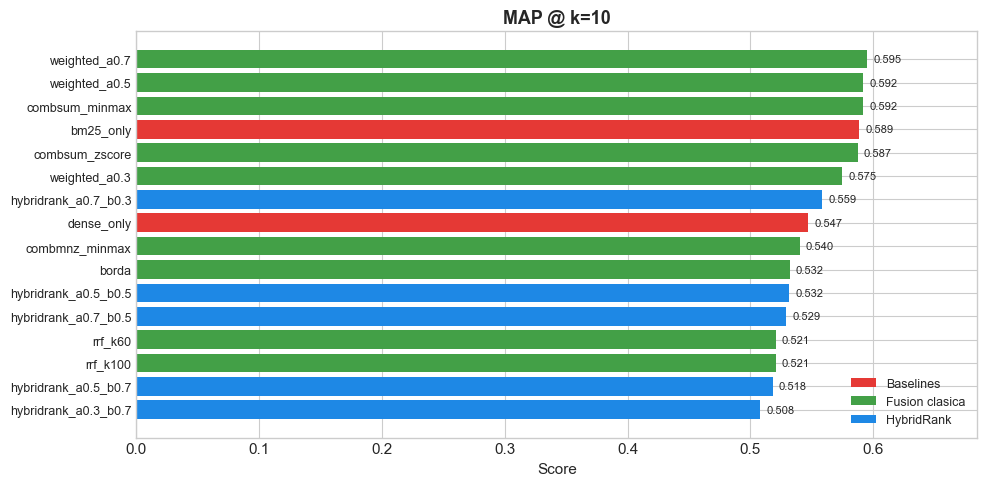

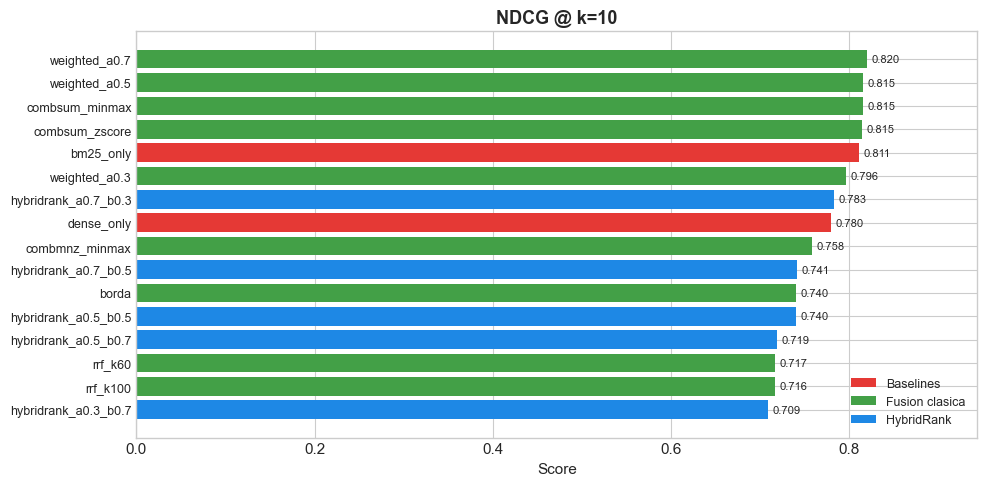

In [10]:
# Comparacion individual por metrica - graficos separados y claros
df_k10 = df[df['top_k'] == 10].copy()
summary_k10 = df_k10.groupby('strategy')[METRIC_COLS].mean()

for metric in METRIC_COLS:
    fig, ax = plt.subplots(figsize=(10, 5))
    data = summary_k10[metric].sort_values(ascending=True)
    
    colors = []
    for name in data.index:
        if name in BASELINES:
            colors.append('#E53935')
        elif 'hybridrank' in name:
            colors.append('#1E88E5')
        else:
            colors.append('#43A047')
    
    bars = ax.barh(range(len(data)), data.values, color=colors)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data.index, fontsize=9)
    ax.set_xlabel('Score')
    ax.set_title(f'{metric.upper()} @ k=10', fontsize=13, fontweight='bold')
    ax.set_xlim(0, min(1.0, data.max() * 1.15))
    
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#E53935', label='Baselines'),
        Patch(facecolor='#43A047', label='Fusion clasica'),
        Patch(facecolor='#1E88E5', label='HybridRank'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'{metric}_k10.png', dpi=150, bbox_inches='tight')
    plt.show()

## 3. Efecto de k en las Metricas (por grupo de estrategia)

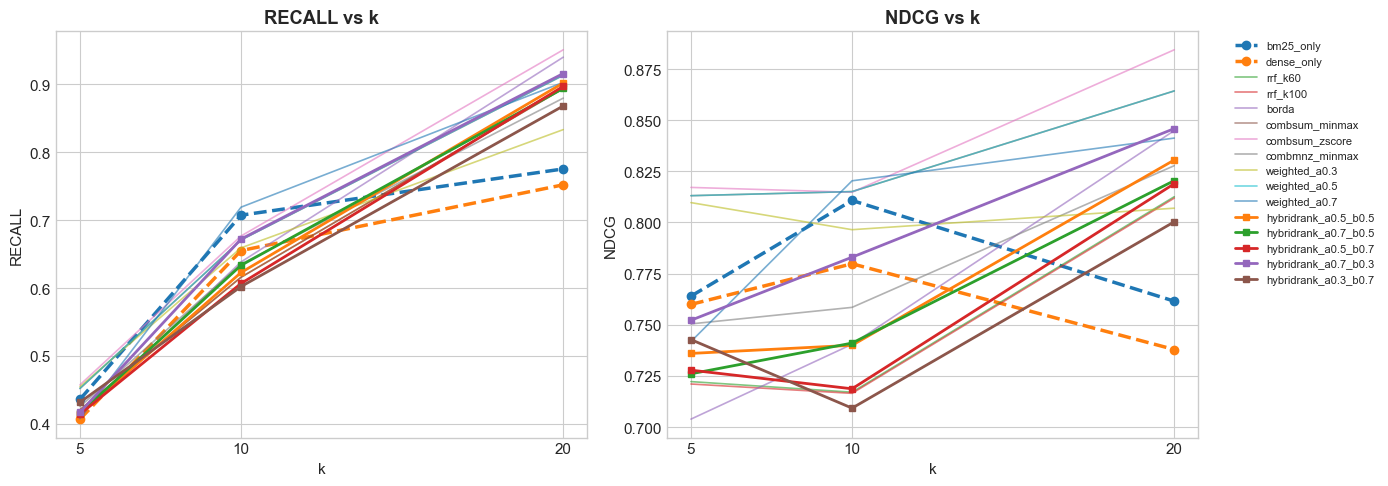

In [11]:
# Lineas: como cambian recall y ndcg al variar k
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['recall', 'ndcg']):
    for strategy in df['strategy'].unique():
        df_s = df[df['strategy'] == strategy].groupby('top_k')[metric].mean()
        
        if strategy in BASELINES:
            style = {'linewidth': 2.5, 'linestyle': '--', 'marker': 'o'}
        elif 'hybridrank' in strategy:
            style = {'linewidth': 2, 'linestyle': '-', 'marker': 's', 'markersize': 5}
        else:
            style = {'linewidth': 1.2, 'linestyle': '-', 'alpha': 0.6}
        
        ax.plot(df_s.index, df_s.values, label=strategy, **style)
    
    ax.set_xlabel('k')
    ax.set_ylabel(metric.upper())
    ax.set_title(f'{metric.upper()} vs k', fontweight='bold')
    ax.set_xticks(sorted(df['top_k'].unique()))

axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metrics_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Analisis por Tipo de Query

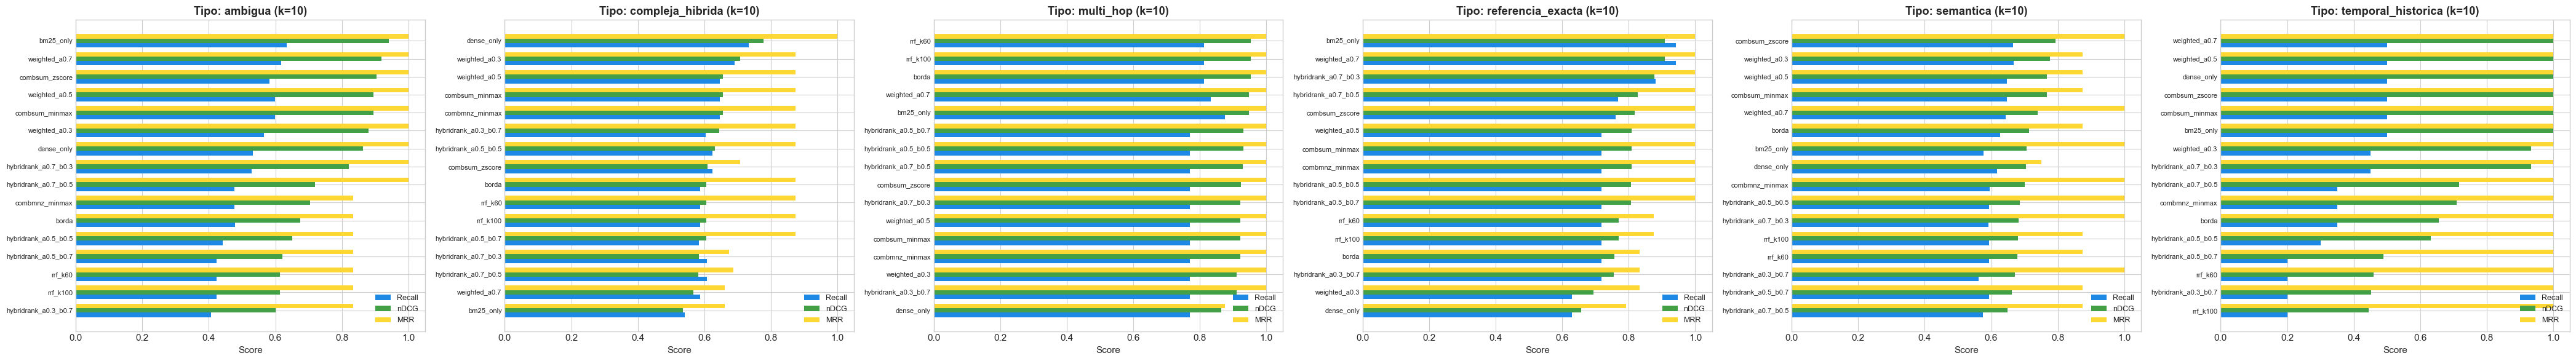

In [12]:
# Rendimiento por tipo de query (k=10)
if 'query_type' in df.columns and df['query_type'].nunique() > 1:
    query_types = sorted(df['query_type'].unique())
    
    fig, axes = plt.subplots(1, len(query_types), figsize=(7 * len(query_types), 6))
    if len(query_types) == 1:
        axes = [axes]
    
    for ax, qt in zip(axes, query_types):
        df_qt = df[(df['query_type'] == qt) & (df['top_k'] == 10)]
        data = df_qt.groupby('strategy')[['recall', 'ndcg', 'mrr']].mean().sort_values('ndcg')
        
        x = np.arange(len(data))
        width = 0.25
        
        ax.barh(x - width, data['recall'], width, label='Recall', color='#1E88E5')
        ax.barh(x, data['ndcg'], width, label='nDCG', color='#43A047')
        ax.barh(x + width, data['mrr'], width, label='MRR', color='#FDD835')
        
        ax.set_yticks(x)
        ax.set_yticklabels(data.index, fontsize=8)
        ax.set_xlabel('Score')
        ax.set_title(f'Tipo: {qt} (k=10)', fontweight='bold')
        ax.legend(fontsize=9)
        ax.set_xlim(0, 1.05)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'by_query_type.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Solo hay un tipo de query o falta la columna query_type')

## 5. Heatmap: Variantes HybridRank (k=10)

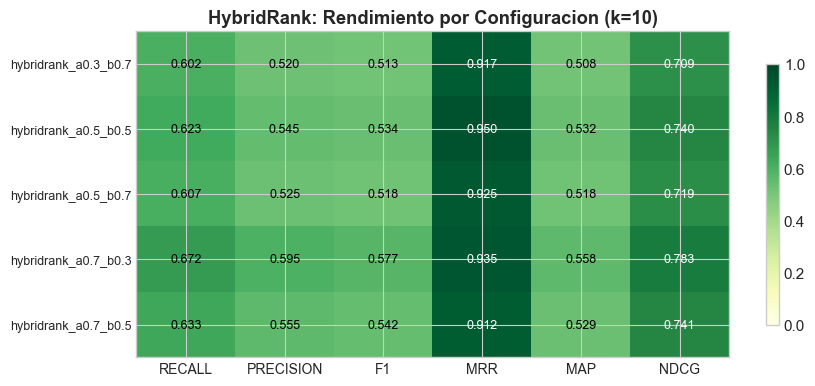

In [13]:
# Heatmap solo de variantes HybridRank
if HR_STRATEGIES:
    df_hr = df[df['strategy'].isin(HR_STRATEGIES) & (df['top_k'] == 10)]
    hr_summary = df_hr.groupby('strategy')[METRIC_COLS].mean().round(4)
    
    fig, ax = plt.subplots(figsize=(9, 4))
    im = ax.imshow(hr_summary.values, cmap='YlGn', aspect='auto', vmin=0, vmax=1)
    
    ax.set_xticks(range(len(hr_summary.columns)))
    ax.set_xticklabels([c.upper() for c in hr_summary.columns], fontsize=10)
    ax.set_yticks(range(len(hr_summary.index)))
    ax.set_yticklabels(hr_summary.index, fontsize=9)
    
    for i in range(len(hr_summary.index)):
        for j in range(len(hr_summary.columns)):
            val = hr_summary.values[i, j]
            color = 'white' if val > 0.7 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9, color=color)
    
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title('HybridRank: Rendimiento por Configuracion (k=10)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'hybridrank_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No se encontraron estrategias HybridRank')

## 6. Mejora Porcentual sobre Baselines

In [14]:
# Mejora porcentual sobre el mejor baseline (k=10)
strategy_means = df_k10.groupby('strategy')[METRIC_COLS].mean()
baseline_means = strategy_means.loc[strategy_means.index.isin(BASELINES)]
best_baseline = baseline_means.max()

# Evitar division por cero
best_baseline_safe = best_baseline.replace(0, np.nan)
improvement = ((strategy_means - best_baseline) / best_baseline_safe * 100).round(2)
improvement = improvement.loc[~improvement.index.isin(BASELINES)]

print('Mejora porcentual sobre mejor baseline (k=10):')
print('(Positivo = supera al mejor baseline)\n')
improvement.style.applymap(
    lambda v: 'color: green; font-weight: bold' if isinstance(v, (int, float)) and v > 0 
    else ('color: red' if isinstance(v, (int, float)) and v < 0 else '')
)

Mejora porcentual sobre mejor baseline (k=10):
(Positivo = supera al mejor baseline)



C:\Users\javie\AppData\Local\Temp\ipykernel_35932\1090384630.py:13: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  improvement.style.applymap(


,recall,precision,f1,mrr,map,ndcg
strategy,,,,,,
borda,-9.730000,-10.240000,-8.860000,-4.340000,-9.650000,-8.670000
combmnz_minmax,-10.180000,-10.240000,-9.140000,1.920000,-8.240000,-6.440000
combsum_minmax,-5.160000,-0.790000,-1.860000,1.920000,0.550000,0.540000
combsum_zscore,-4.330000,-0.790000,-1.710000,1.020000,-0.250000,0.490000
hybridrank_a0.3_b0.7,-14.860000,-18.110000,-15.410000,-1.660000,-13.690000,-12.520000
hybridrank_a0.5_b0.5,-11.930000,-14.170000,-11.980000,1.920000,-9.680000,-8.730000
hybridrank_a0.5_b0.7,-14.210000,-17.320000,-14.700000,-0.770000,-11.990000,-11.350000
hybridrank_a0.7_b0.3,-4.970000,-6.300000,-4.860000,0.310000,-5.130000,-3.420000
hybridrank_a0.7_b0.5,-10.430000,-12.600000,-10.580000,-2.110000,-10.090000,-8.600000
